# Random Forest Feature Importance Analysis
## Predicting Resultado Macro (Success/Non-Success)

This notebook analyzes which variables are most important for predicting case outcomes using both the process results and subsidies datasets.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Explore Data

In [21]:
# Load the datasets
results_df = pd.read_csv('data/Hackaton_Enter_Base_Candidatos.xlsx - Resultados dos processos.csv')
subsidies_df = pd.read_csv('data/Hackaton_Enter_Base_Candidatos.xlsx - Subsídios disponibilizados.csv', skiprows=1)

print("Results Dataset Shape:", results_df.shape)
print("\nResults Dataset Columns:", results_df.columns.tolist())
print("\nFirst rows of Results:")
print(results_df.head())

print("\n" + "="*80)
print("\nSubsidies Dataset Shape:", subsidies_df.shape)
print("\nSubsidies Dataset Columns:", subsidies_df.columns.tolist())
print("\nFirst rows of Subsidies:")
print(subsidies_df.head())

Results Dataset Shape: (60000, 8)

Results Dataset Columns: ['Número do processo', 'UF', 'Assunto', 'Sub-assunto', 'Resultado macro', 'Resultado micro', 'Valor da causa', 'Valor da condenação/indenização']

First rows of Results:
          Número do processo  UF                 Assunto Sub-assunto  \
0  1764352-89.2025.8.06.1818  CE  Não reconhece operação    Genérico   
1  5638325-36.2025.8.17.4124  PE  Não reconhece operação       Golpe   
2  1037491-89.2025.8.18.1658  PI  Não reconhece operação       Golpe   
3  9547931-23.2025.8.04.4188  AM  Não reconhece operação       Golpe   
4  9999446-69.2025.8.04.4264  AM  Não reconhece operação       Golpe   

  Resultado macro      Resultado micro Valor da causa  \
0       Não Êxito  Parcial procedência      13,534.00   
1       Não Êxito  Parcial procedência       7,883.63   
2       Não Êxito  Parcial procedência       8,561.97   
3           Êxito        Improcedência       5,693.13   
4           Êxito        Improcedência       8,515.6

In [22]:
# Check for missing values and data types
print("Results DataFrame Info:")
print(results_df.info())
print("\nResults Missing Values:")
print(results_df.isnull().sum())

print("\n" + "="*80)
print("\nSubsidies DataFrame Info:")
print(subsidies_df.info())
print("\nSubsidies Missing Values:")
print(subsidies_df.isnull().sum())

Results DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Número do processo               60000 non-null  object
 1   UF                               60000 non-null  object
 2   Assunto                          60000 non-null  object
 3   Sub-assunto                      60000 non-null  object
 4   Resultado macro                  60000 non-null  object
 5   Resultado micro                  60000 non-null  object
 6   Valor da causa                   60000 non-null  object
 7   Valor da condenação/indenização  60000 non-null  object
dtypes: object(8)
memory usage: 3.7+ MB
None

Results Missing Values:
Número do processo                 0
UF                                 0
Assunto                            0
Sub-assunto                        0
Resultado macro                    0
Res

Resultado Macro Distribution:
Resultado macro
Êxito        41733
Não Êxito    18267
Name: count, dtype: int64

Proportions:
Resultado macro
Êxito        0.69555
Não Êxito    0.30445
Name: proportion, dtype: float64


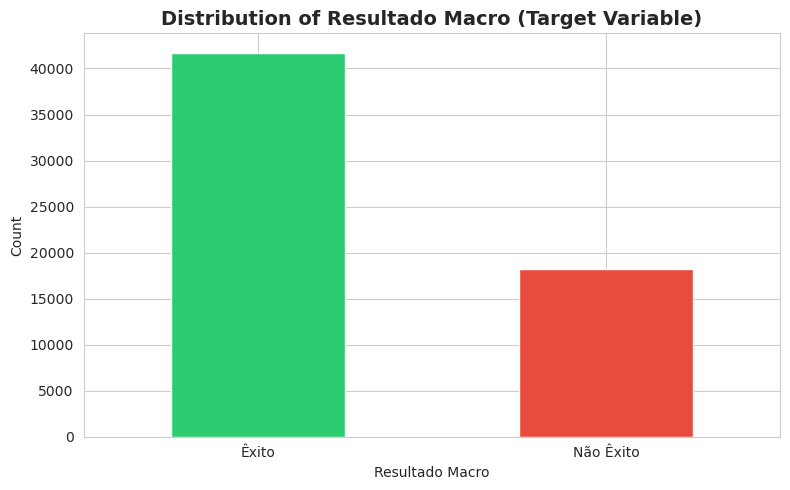

In [23]:
# Check the target variable distribution
print("Resultado Macro Distribution:")
print(results_df['Resultado macro'].value_counts())
print("\nProportions:")
print(results_df['Resultado macro'].value_counts(normalize=True))

# Visualize target distribution
plt.figure(figsize=(8, 5))
results_df['Resultado macro'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Resultado Macro (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Resultado Macro')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Merge Datasets

In [24]:
# Fix column names to enable proper merging
results_df.rename(columns={'Número do processo': 'process_id'}, inplace=True)
subsidies_df.rename(columns={'Número do processos': 'process_id'}, inplace=True)

# Merge the datasets
merged_df = pd.merge(results_df, subsidies_df, on='process_id', how='inner')

print(f"Merged Dataset Shape: {merged_df.shape}")
print(f"\nColumns in merged dataset: {merged_df.columns.tolist()}")
print(f"\nFirst rows:")
print(merged_df.head())

# Split merged data: 50% base (exploration/analysis), 50% for the model (train + test)
base_df = merged_df.sample(frac=0.5, random_state=42)
model_df = merged_df.drop(base_df.index).reset_index(drop=True)

print(f"\n{'='*80}")
print(f"Base (exploration) set:  {len(base_df)} rows")
print(f"Model (train+test) set:  {len(model_df)} rows")


Merged Dataset Shape: (60000, 14)

Columns in merged dataset: ['process_id', 'UF', 'Assunto', 'Sub-assunto', 'Resultado macro', 'Resultado micro', 'Valor da causa', 'Valor da condenação/indenização', 'Contrato', 'Extrato', 'Comprovante de crédito', 'Dossiê', 'Demonstrativo de evolução da dívida', 'Laudo referenciado']

First rows:
                  process_id  UF                 Assunto Sub-assunto  \
0  1764352-89.2025.8.06.1818  CE  Não reconhece operação    Genérico   
1  5638325-36.2025.8.17.4124  PE  Não reconhece operação       Golpe   
2  1037491-89.2025.8.18.1658  PI  Não reconhece operação       Golpe   
3  9547931-23.2025.8.04.4188  AM  Não reconhece operação       Golpe   
4  9999446-69.2025.8.04.4264  AM  Não reconhece operação       Golpe   

  Resultado macro      Resultado micro Valor da causa  \
0       Não Êxito  Parcial procedência      13,534.00   
1       Não Êxito  Parcial procedência       7,883.63   
2       Não Êxito  Parcial procedência       8,561.97   
3     

## 3. Prepare Data for Random Forest

In [25]:
# Create a working copy from the model portion only
df = model_df.copy()

# Target variable
y = df['Resultado macro']

# Select features (exclude process_id, target variable, and Resultado micro
# to avoid leaking outcome information into the predictors)
feature_cols = ['UF', 'Assunto', 'Sub-assunto',
                 'Contrato', 'Extrato', 'Comprovante de crédito',
                 'Dossiê', 'Demonstrativo de evolução da dívida', 'Laudo referenciado']

X = df[feature_cols].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures to be used:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")


Features shape: (30000, 9)
Target shape: (30000,)

Features to be used:
  1. UF
  2. Assunto
  3. Sub-assunto
  4. Contrato
  5. Extrato
  6. Comprovante de crédito
  7. Dossiê
  8. Demonstrativo de evolução da dívida
  9. Laudo referenciado


In [27]:
# Encode categorical variables
le_dict = {}
categorical_features = ['UF', 'Assunto', 'Sub-assunto']

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le
    print(f"\n{col} - Unique values encoded: {len(le.classes_)}")
    if len(le.classes_) <= 10:
        print(f"  Classes: {list(le.classes_)}")

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"\nTarget classes: {le_target.classes_}")

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"\nFeature matrix after encoding:")
print(X.head())



UF - Unique values encoded: 26

Assunto - Unique values encoded: 1
  Classes: ['0']

Sub-assunto - Unique values encoded: 2
  Classes: ['0', '1']

Target classes: ['Não Êxito' 'Êxito']

Final feature matrix shape: (30000, 9)

Feature matrix after encoding:
   UF  Assunto  Sub-assunto  Contrato  Extrato  Comprovante de crédito  \
0   8        0            1         0        1                       1   
1  12        0            1         1        1                       1   
2  15        0            0         1        1                       1   
3  20        0            1         0        1                       0   
4   6        0            1         1        1                       0   

   Dossiê  Demonstrativo de evolução da dívida  Laudo referenciado  
0       1                                    1                   0  
1       1                                    1                   0  
2       1                                    0                   1  
3       1            

## 4. Train Random Forest Model

In [28]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le_target.classes_[u]}: {c}")

Training set size: 24000
Test set size: 6000

Class distribution in training set:
  Não Êxito: 7323
  Êxito: 16677


In [29]:
# Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print(f"Number of features used: {X_train.shape[1]}")
print(f"Target classes: {list(le_target.classes_)}")


Random Forest model trained successfully!
Number of features used: 9
Target classes: ['Não Êxito', 'Êxito']


## 5. Model Evaluation

In [30]:
# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\n" + "="*80)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=le_target.classes_))

print("\n" + "="*80)
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

Training Accuracy: 0.8915
Test Accuracy: 0.8558


Classification Report (Test Set):
              precision    recall  f1-score   support

   Não Êxito       0.79      0.72      0.75      1809
       Êxito       0.88      0.92      0.90      4191

    accuracy                           0.86      6000
   macro avg       0.83      0.82      0.82      6000
weighted avg       0.85      0.86      0.85      6000



Confusion Matrix (Test Set):
[[1297  512]
 [ 353 3838]]


## 6. Feature Importance Analysis

In [31]:
# Extract feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
print("="*60)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:40s} : {row['Importance']:8.6f} ({row['Importance']*100:6.2f}%)")

print(f"\nTop 5 Most Important Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']} ({row['Importance']*100:.2f}%)")

Feature Importance Ranking:
Contrato                                 : 0.457541 ( 45.75%)
Extrato                                  : 0.280266 ( 28.03%)
UF                                       : 0.133163 ( 13.32%)
Comprovante de crédito                   : 0.064154 (  6.42%)
Sub-assunto                              : 0.036589 (  3.66%)
Demonstrativo de evolução da dívida      : 0.011838 (  1.18%)
Laudo referenciado                       : 0.008994 (  0.90%)
Dossiê                                   : 0.007455 (  0.75%)
Assunto                                  : 0.000000 (  0.00%)

Top 5 Most Important Features:
  4. Contrato (45.75%)
  5. Extrato (28.03%)
  1. UF (13.32%)
  6. Comprovante de crédito (6.42%)
  3. Sub-assunto (3.66%)


## 7. Visualizations

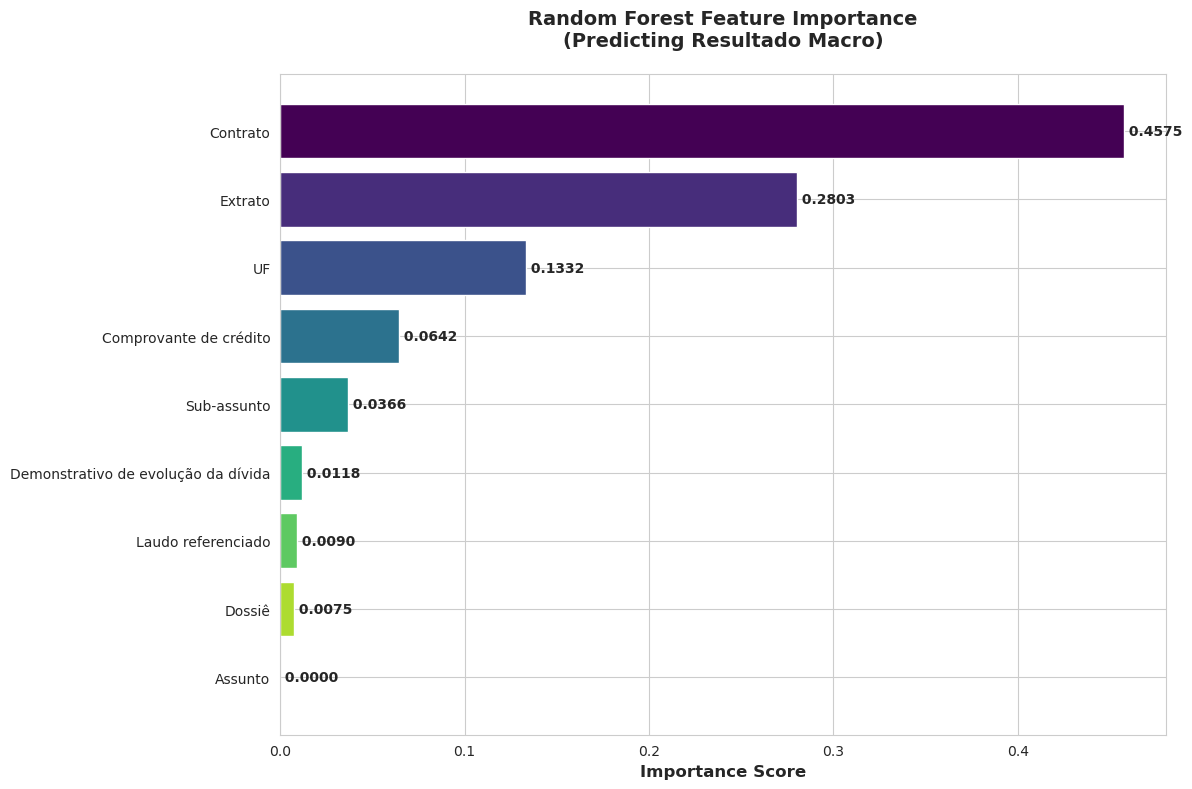

Feature Importance chart generated!


In [32]:
# Plot 1: Feature Importance Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
bars = ax.barh(range(len(importance_df)), importance_df['Importance'].values, color=colors)
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['Feature'].values)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Feature Importance\n(Predicting Resultado Macro)', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels on bars
for i, (idx, row) in enumerate(importance_df.iterrows()):
    ax.text(row['Importance'], i, f" {row['Importance']:.4f}", 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Feature Importance chart generated!")

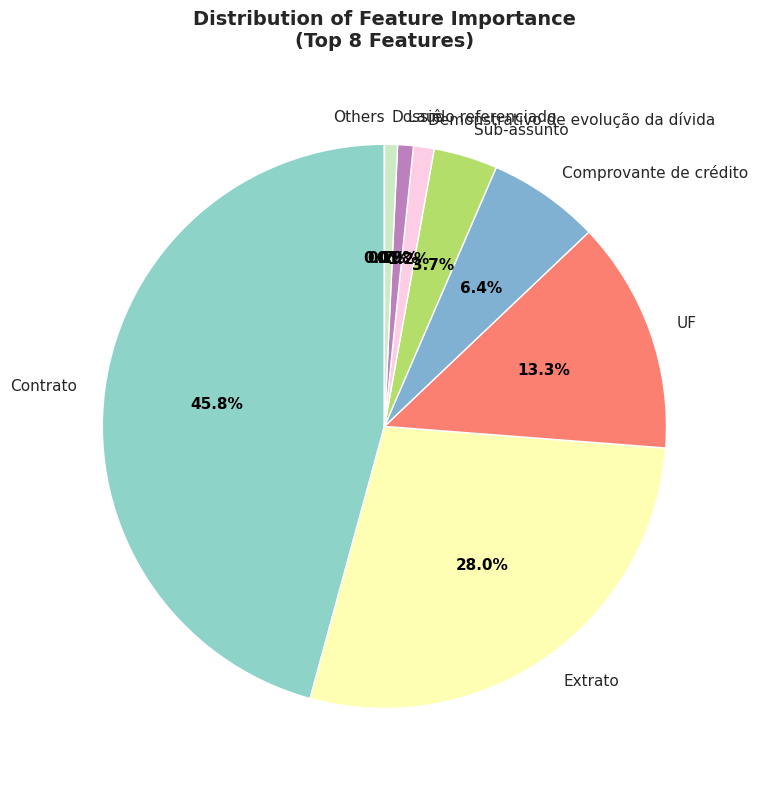

Pie chart generated!


In [33]:
# Plot 2: Feature Importance as Pie Chart (Top 8)
top_n = 8
top_features = importance_df.head(top_n)
other_importance = importance_df.iloc[top_n:]['Importance'].sum()

pie_data = list(top_features['Importance'].values) + [other_importance]
pie_labels = list(top_features['Feature'].values) + ['Others']

fig, ax = plt.subplots(figsize=(12, 8))
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90, textprops={'fontsize': 11})
ax.set_title('Distribution of Feature Importance\n(Top 8 Features)', 
             fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

print("Pie chart generated!")

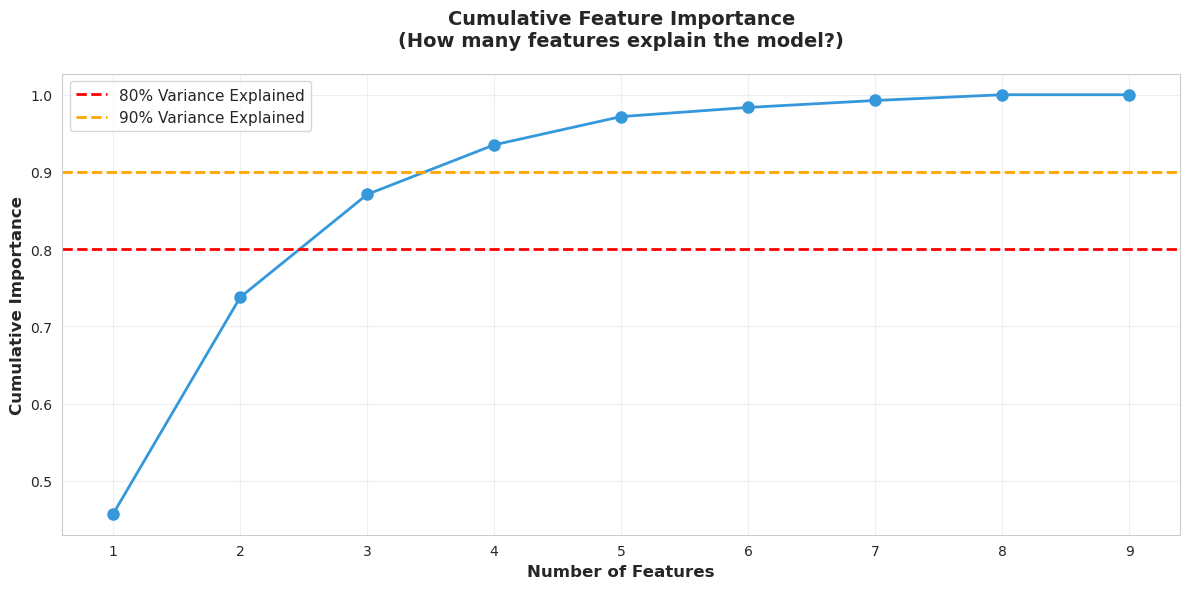


Features needed to explain:
  80% of variance: 3 features
  90% of variance: 4 features


In [34]:
# Plot 3: Cumulative Feature Importance
cumsum_importance = np.cumsum(importance_df['Importance'].values)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, len(importance_df)+1), cumsum_importance, marker='o', 
        linewidth=2, markersize=8, color='#3498db')
ax.axhline(y=0.8, color='r', linestyle='--', linewidth=2, label='80% Variance Explained')
ax.axhline(y=0.9, color='orange', linestyle='--', linewidth=2, label='90% Variance Explained')
ax.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Feature Importance\n(How many features explain the model?)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xticks(range(1, len(importance_df)+1))
plt.tight_layout()
plt.show()

# Find how many features needed for 80% and 90%
features_80 = np.where(cumsum_importance >= 0.8)[0][0] + 1
features_90 = np.where(cumsum_importance >= 0.9)[0][0] + 1
print(f"\nFeatures needed to explain:")
print(f"  80% of variance: {features_80} features")
print(f"  90% of variance: {features_90} features")

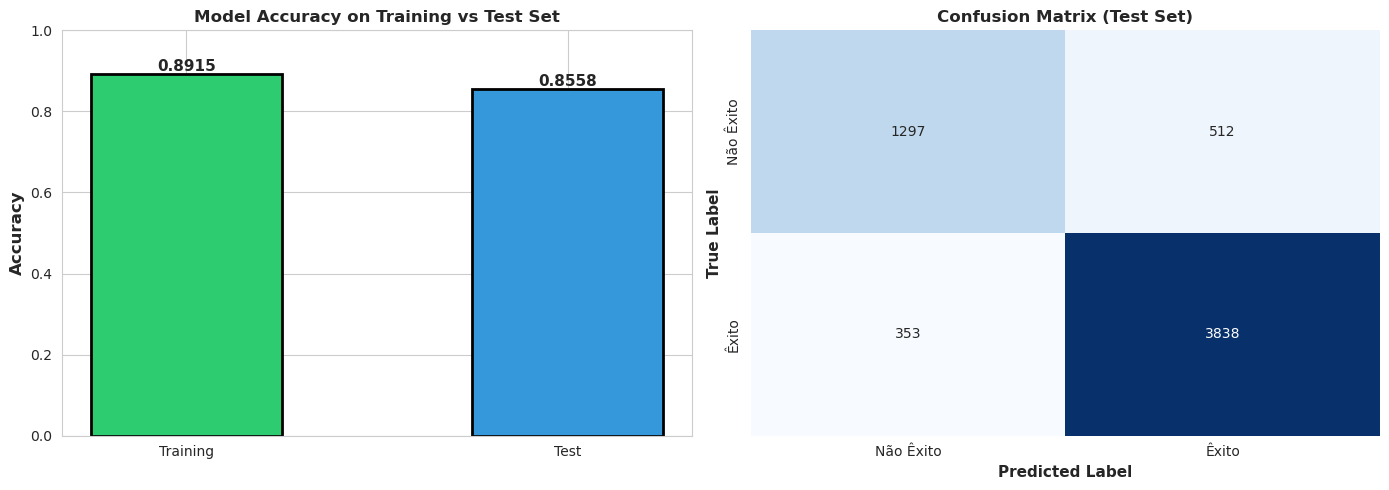

Performance comparison charts generated!


In [35]:
# Plot 4: Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
accuracies = [train_accuracy, test_accuracy]
labels = ['Training', 'Test']
colors_acc = ['#2ecc71', '#3498db']
bars = ax1.bar(labels, accuracies, color=colors_acc, width=0.5, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy on Training vs Test Set', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Confusion matrix heatmap
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
ax2.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Performance comparison charts generated!")

## 8. Key Insights Summary

In [37]:
print("\n" + "="*80)
print("RANDOM FOREST ANALYSIS - KEY INSIGHTS")
print("="*80)

print(f"\n1. MODEL PERFORMANCE:")
print(f"   - Training Accuracy: {train_accuracy*100:.2f}%")
print(f"   - Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   - Overfitting Gap: {(train_accuracy - test_accuracy)*100:.2f}%")

print(f"\n2. TOP 5 MOST IMPORTANT VARIABLES:")
for i, (idx, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['Feature']:40s} - {row['Importance']*100:6.2f}%")

print(f"\n3. FEATURE CATEGORIES:")
subsidy_features = ['Contrato', 'Extrato', 'Comprovante de crédito', 
                     'Dossiê', 'Demonstrativo de evolução da dívida', 'Laudo referenciado']
other_features = [f for f in feature_cols if f not in subsidy_features]

subsidy_importance = importance_df[importance_df['Feature'].isin(subsidy_features)]['Importance'].sum()
other_importance = importance_df[importance_df['Feature'].isin(other_features)]['Importance'].sum()

print(f"   - Subsidy Indicators: {subsidy_importance*100:.2f}%")
print(f"   - Case Characteristics: {other_importance*100:.2f}%")

print(f"\n4. DATASET COVERAGE:")
print(f"   - Total cases analyzed: {len(merged_df)}")
print(f"   - Training set: {len(X_train)} cases")
print(f"   - Test set: {len(X_test)} cases")

print(f"\n5. TARGET DISTRIBUTION:")
for cls in le_target.classes_:
    count = (y == cls).sum()
    pct = (y == cls).sum() / len(y) * 100
    print(f"   - {cls}: {count} cases ({pct:.1f}%)")

print("\n" + "="*80)


RANDOM FOREST ANALYSIS - KEY INSIGHTS

1. MODEL PERFORMANCE:
   - Training Accuracy: 89.15%
   - Test Accuracy: 85.58%
   - Overfitting Gap: 3.57%

2. TOP 5 MOST IMPORTANT VARIABLES:
   1. Contrato                                 -  45.75%
   2. Extrato                                  -  28.03%
   3. UF                                       -  13.32%
   4. Comprovante de crédito                   -   6.42%
   5. Sub-assunto                              -   3.66%

3. FEATURE CATEGORIES:
   - Subsidy Indicators: 83.02%
   - Case Characteristics: 16.98%

4. DATASET COVERAGE:
   - Total cases analyzed: 60000
   - Training set: 24000 cases
   - Test set: 6000 cases

5. TARGET DISTRIBUTION:
   - Não Êxito: 9132 cases (30.4%)
   - Êxito: 20868 cases (69.6%)

